In [ ]:
!pip install yfinance
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.style.use('dark_background')
print("Libraries ready!")

Libraries ready!


In [ ]:
import yfinance as yf

# Real NSE stock data - last 1 year
stocks = {
    'TCS': 'TCS.NS',
    'Infosys': 'INFY.NS',
    'Reliance': 'RELIANCE.NS'

}

data=yf.download(list(stocks.values()), period='1y') ['Close']
data.columns = list(stocks.keys())
data.dropna(inplace=True)

print("Data download!")
print(data.tail())

/tmp/ipykernel_7789/476827614.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(list(stocks.values()), period='1y') ['Close']
[*********************100%***********************]  3 of 3 completed

Data download!
                    TCS      Infosys     Reliance
Date                                             
2026-04-10  1292.500000  1350.199951  2524.300049
2026-04-13  1276.800049  1315.099976  2472.600098
2026-04-15  1305.300049  1344.099976  2554.899902
2026-04-16  1319.199951  1343.300049  2576.899902
2026-04-17  1318.699951  1365.000000  2581.500000


In [ ]:
returns = data.pct_change().dropna()

print("Average Daily Return:")
print((returns.mean()*100).round(3), "\n")

print("Volatility (Std Dev):")
print((returns.std()*100).round(3))


Average Daily Return:
TCS        -0.005
Infosys     0.038
Reliance   -0.076
dtype: float64 

Volatility (Std Dev):
TCS         1.595
Infosys     1.287
Reliance    1.370
dtype: float64


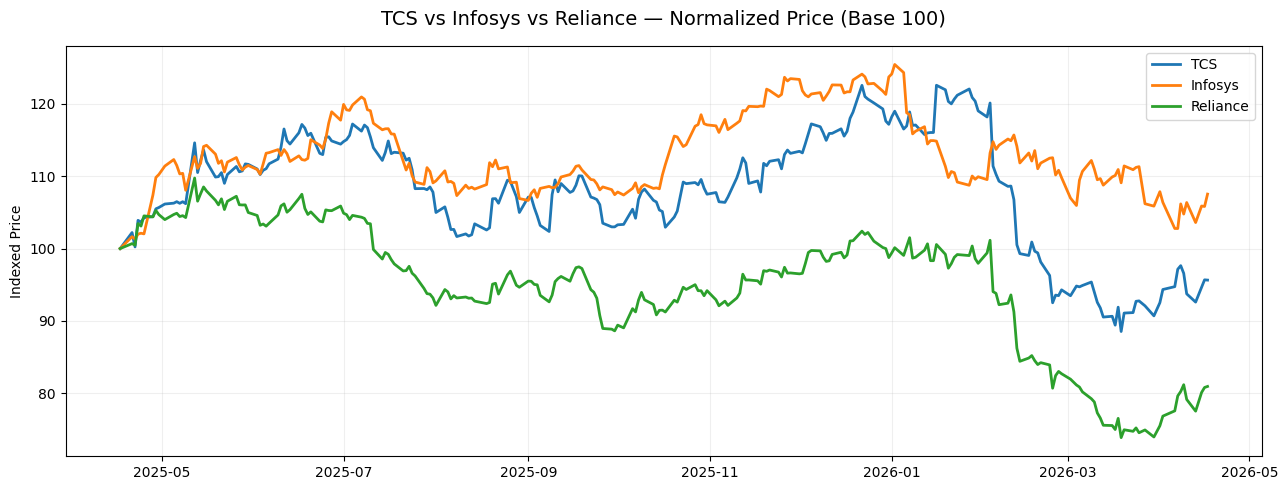

✅ Chart saved!


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 5))

for col in data.columns:
    normalized = data[col] / data[col].iloc[0] * 100
    ax.plot(data.index, normalized, label=col, linewidth=2)

ax.set_title('TCS vs Infosys vs Reliance — Normalized Price (Base 100)',
             fontsize=14, pad=15)
ax.set_ylabel('Indexed Price')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('price_trend.png', dpi=150)
plt.show()
print("✅ Chart saved!")

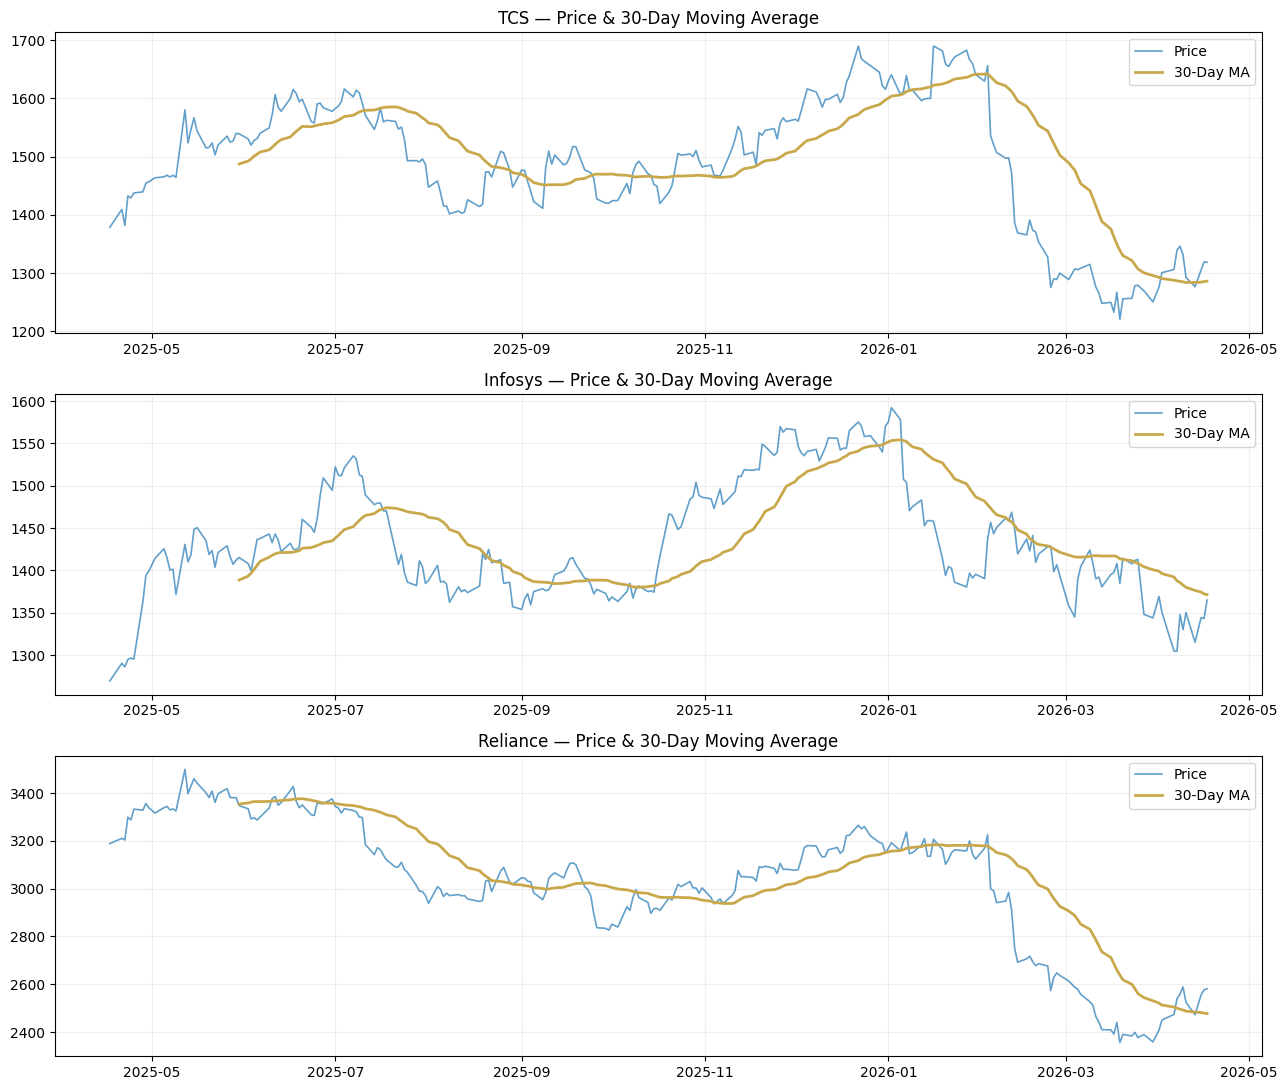

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11))

for i, stock in enumerate(data.columns):
    ax = axes[i]
    ax.plot(data.index, data[stock], label='Price', alpha=0.7, linewidth=1.2)
    ax.plot(data.index, data[stock].rolling(30).mean(),
            label='30-Day MA', linewidth=2, color='#c9a84c')
    ax.set_title(f'{stock} — Price & 30-Day Moving Average')
    ax.legend()
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('moving_averages.png', dpi=150)
plt.show()

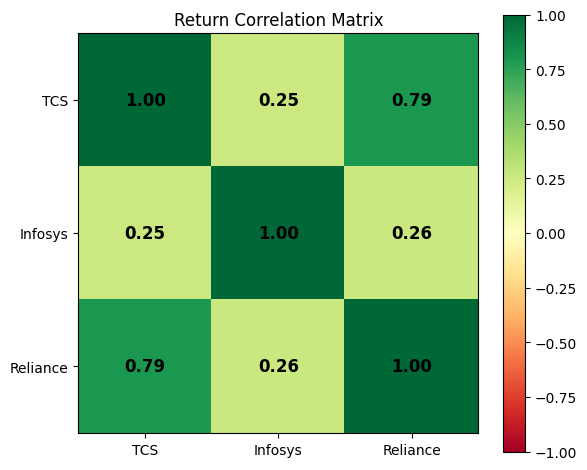

In [ ]:
import matplotlib.patches as mpatches

corr = returns.corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im)

ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns)
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}',
                ha='center', va='center', fontsize=12, fontweight='bold')

ax.set_title('Return Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation.png', dpi=150)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

summary = pd.DataFrame({
    'Avg Daily Return (%)': (returns.mean() * 100).round(3),
    'Volatility (%)': (returns.std() * 100).round(3),
    'Annualized Return (%)': (returns.mean() * 252 * 100).round(2),
    'Annualized Risk (%)': (returns.std() * np.sqrt(252) * 100).round(2),
    'Sharpe Ratio (approx)': ((returns.mean() * 252) / (returns.std() * np.sqrt(252))).round(3)
})

print("=" * 60)
print("         STOCK ANALYSIS SUMMARY — DHEISIRI ANANDAESWARAN")
print("=" * 60)
print(summary.to_string())

         STOCK ANALYSIS SUMMARY — DHEISIRI ANANDAESWARAN
          Avg Daily Return (%)  Volatility (%)  Annualized Return (%)  Annualized Risk (%)  Sharpe Ratio (approx)
TCS                     -0.005           1.595                  -1.35                25.32                 -0.054
Infosys                  0.038           1.287                   9.48                20.44                  0.464
Reliance                -0.076           1.370                 -19.17                21.75                 -0.881


Insight1 — Best Performer:
Infosys outperformed with a 9.48% annualized return and the lowest volatility, making it the most efficient pick among the three.
Insight2 — Worst Performer:
Reliance struggled the most, posting a -19.17% annualized loss and the worst Sharpe Ratio of -0.881, signaling poor risk-adjusted performance.
Insight3 — Risk vs Return:
Only Infosys rewarded investors on a risk-adjusted basis — TCS and Reliance both delivered negative returns despite carrying significant market risk.